## Accessing DM-EFD data


In this notebook, I used Robert Lupton's code that unpacks the 100 samples/second datapoints in the EFD
to plot the Nasmyth2 motor torque during a run when we were varying the Nasmyth2 angle to investigate
the horizontal banding problem caused (probably) by electrical noise.

In [4]:
import sys, time, os

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.fft import fft, fftfreq

from astropy.time import Time, TimeDelta
from lsst_efd_client import EfdClient

We'll access the EFD instance deployed at the Summit.

In [5]:
client = EfdClient('summit_efd')

In [6]:
# Lupton's unpacking code

def merge_packed_time_series(packed_dataframe, base_field, stride=1, 
                             ref_timestamp_col="cRIO_timestamp", internal_time_scale="tai"):
    """Select fields that are time samples and unpack them into a dataframe.
            Parameters
            ----------
            packedDF : `pandas.DataFrame`
                packed data frame containing the desired data
            base_field :  `str`
                Base field name that will be expanded to query all
                vector entries.
            stride : `int`, optional
                Only use every stride value when unpacking.  Must be a factor
                of the number of packed values.
                (1 by default)
            ref_timestamp_col : `str`, optional
                Name of the field name to use to assign timestamps to unpacked
                vector fields (default is 'cRIO_timestamp').
            internal_time_scale : `str`, optional
                Time scale to use when converting times to internal formats
                ('tai' by default). Equivalent to EfdClient.internal_scale
        Returns
            -------
            result : `pandas.DataFrame`
                A `pandas.DataFrame` containing the results of the query.
            """
    
    packed_fields = [k for k in packed_dataframe.keys() if k.startswith(base_field)]
    packed_fields = sorted(packed_fields, key=lambda k: int(k[len(base_field):]))  # sort by pack ID
    npack = len(packed_fields)
    if npack%stride != 0:
        raise RuntimeError(f"Stride must be a factor of the number of packed fields: {stride} v. {npack}")
    packed_len = len(packed_dataframe)
    n_used = npack//stride   # number of raw fields being used
    output = np.empty(n_used*packed_len)
    times = np.empty_like(output, dtype=packed_dataframe[ref_timestamp_col][0])
    
    if packed_len == 1:
        dt = 0
    else:
        dt = (packed_dataframe[ref_timestamp_col][1] - packed_dataframe[ref_timestamp_col][0])/npack
    for i in range(0, npack, stride):
        i0 = i//stride
        output[i0::n_used] = packed_dataframe[f"{base_field}{i}"]
        times[i0::n_used] = packed_dataframe[ref_timestamp_col] + i*dt
     
    timestamps = Time(times, format='unix', scale=internal_time_scale).datetime64
    return pd.DataFrame({base_field:output, "times":times}, index=timestamps)

In [55]:
t_end = Time("2021-04-08T20:26:00", scale='tai')   # timestamp at end of desired data 
nsec = 1.0*3600 # how many seconds of data to retrieve
nasmyth_torque = await client.select_time_series("lsst.sal.ATMCS.measuredTorque", ['*'],
                                              t_end - TimeDelta(nsec, format='sec'), t_end)
torque = merge_packed_time_series(nasmyth_torque, 'nasmyth2MotorTorque', stride=1)
nasmyth_angle = await client.select_time_series("lsst.sal.ATMCS.mount_Nasmyth_Encoders", ['*'],
                                              t_end - TimeDelta(nsec, format='sec'), t_end)
angle = merge_packed_time_series(nasmyth_angle, 'nasmyth2CalculatedAngle', stride=1)


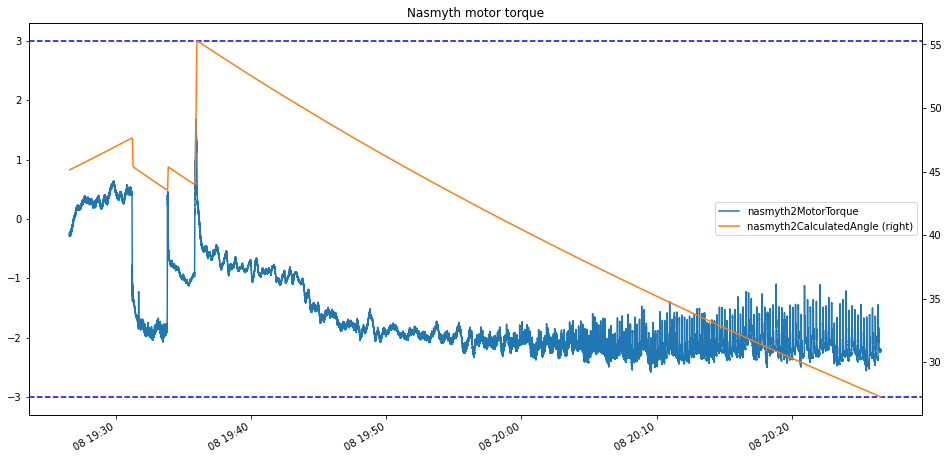

In [57]:
ax1 = torque['nasmyth2MotorTorque'].plot(figsize=(16,8), title='Nasmyth motor torque', legend=True)
ax1.axhline(3.0, color="blue", linestyle="--")
ax1.axhline(-3.0, color="blue", linestyle="--")
angle['nasmyth2CalculatedAngle'].plot(legend=True, secondary_y=True)
plt.savefig("/home/craiglagegit/DATA/Nasmyth2_Torque_Guiding_08Apr21.pdf")

In [81]:
t_end = Time("2021-04-08T20:45:00", scale='tai')   # timestamp at end of desired data 
nsec = 0.3*3600 # how many seconds of data to retrieve
nasmyth_torque = await client.select_time_series("lsst.sal.ATMCS.measuredTorque", ['*'],
                                              t_end - TimeDelta(nsec, format='sec'), t_end)
torque = merge_packed_time_series(nasmyth_torque, 'nasmyth2MotorTorque', stride=1)
nasmyth_angle = await client.select_time_series("lsst.sal.ATMCS.mount_Nasmyth_Encoders", ['*'],
                                              t_end - TimeDelta(nsec, format='sec'), t_end)
angle = merge_packed_time_series(nasmyth_angle, 'nasmyth2CalculatedAngle', stride=1)


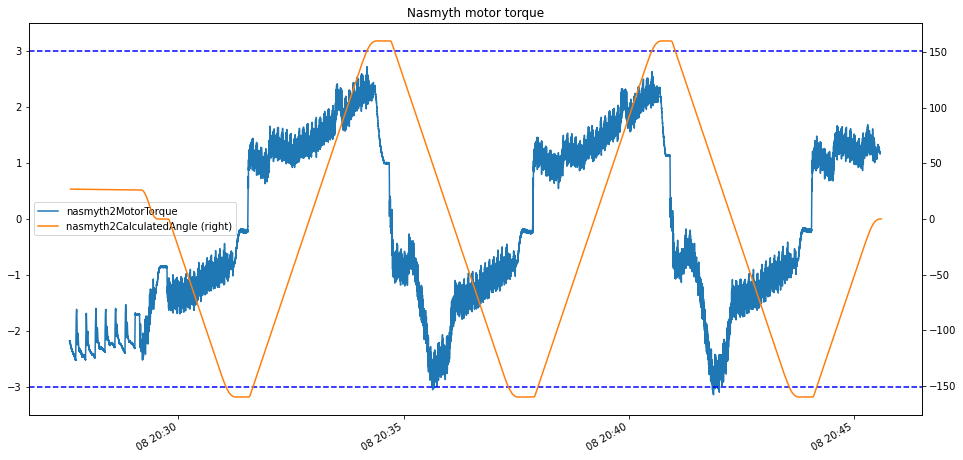

In [82]:
ax1 = torque['nasmyth2MotorTorque'].plot(figsize=(16,8), title='Nasmyth motor torque', legend=True)
ax1.axhline(3.0, color="blue", linestyle="--")
ax1.axhline(-3.0, color="blue", linestyle="--")
plt.ylim(-3.5,3.5)
angle['nasmyth2CalculatedAngle'].plot(legend=True, secondary_y=True)
plt.savefig("/home/craiglagegit/DATA/Nasmyth2_Torque_Slewing_08Apr21.pdf")

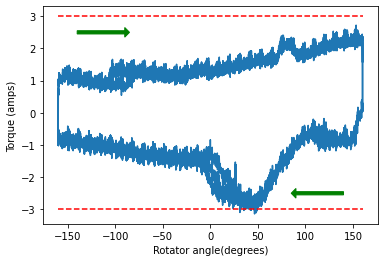

In [83]:
torqueList = torque.values.tolist()
angleList = angle.values.tolist()
plt.figure()
plt.plot(np.array(angleList)[:,0],np.array(torqueList)[:,0])
plt.plot([-160,160],[3.0,3.0], color='red', ls='--')
plt.plot([-160,160],[-3.0,-3.0], color='red', ls='--')
plt.arrow(-140, 2.5, 50,0, width=0.1,head_length = 5.0, color='green')
plt.arrow(140, -2.5, -50,0, width=0.1,head_length = 5.0, color='green')
plt.xlabel("Rotator angle(degrees)")
plt.ylabel("Torque (amps)")
plt.savefig("/home/craiglagegit/DATA/Torque_vs_Angle_08Apr21.pdf")

In [84]:
t_end = Time("2021-04-08T22:04:00", scale='tai')   # timestamp at end of desired data 
nsec = 0.15*3600 # how many seconds of data to retrieve
nasmyth_torque = await client.select_time_series("lsst.sal.ATMCS.measuredTorque", ['*'],
                                              t_end - TimeDelta(nsec, format='sec'), t_end)
torque = merge_packed_time_series(nasmyth_torque, 'nasmyth2MotorTorque', stride=1)
nasmyth_angle = await client.select_time_series("lsst.sal.ATMCS.mount_Nasmyth_Encoders", ['*'],
                                              t_end - TimeDelta(nsec, format='sec'), t_end)
angle = merge_packed_time_series(nasmyth_angle, 'nasmyth2CalculatedAngle', stride=1)


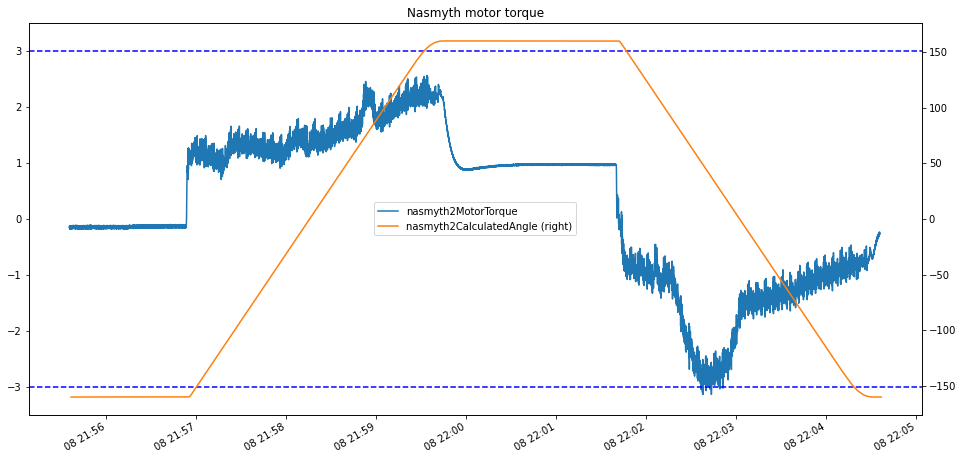

In [85]:
ax1 = torque['nasmyth2MotorTorque'].plot(figsize=(16,8), title='Nasmyth motor torque', legend=True)
ax1.axhline(3.0, color="blue", linestyle="--")
ax1.axhline(-3.0, color="blue", linestyle="--")
plt.ylim(-3.5,3.5)
angle['nasmyth2CalculatedAngle'].plot(legend=True, secondary_y=True)
plt.savefig("/home/craiglagegit/DATA/Nasmyth2_Torque_Slewing2_08Apr21.pdf")

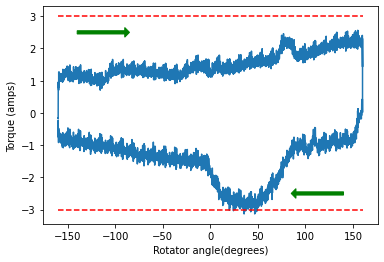

In [86]:
torqueList = torque.values.tolist()
angleList = angle.values.tolist()
plt.figure()
plt.plot(np.array(angleList)[:,0],np.array(torqueList)[:,0])
plt.plot([-160,160],[3.0,3.0], color='red', ls='--')
plt.plot([-160,160],[-3.0,-3.0], color='red', ls='--')
plt.arrow(-140, 2.5, 50,0, width=0.1,head_length = 5.0, color='green')
plt.arrow(140, -2.5, -50,0, width=0.1,head_length = 5.0, color='green')
plt.xlabel("Rotator angle(degrees)")
plt.ylabel("Torque (amps)")
plt.savefig("/home/craiglagegit/DATA/Torque_vs_Angle2_08Apr21.pdf")